#데이터 불러오기(API)

In [ ]:
import os
import pandas as pd
import numpy as np

def get_data_path():
    target = 'Telco-Customer-Churn2025.csv'
    curr = os.path.abspath(os.getcwd())
    while True:
        candidate1 = os.path.join(curr, 'data', target)
        if os.path.exists(candidate1):
            return candidate1
        candidate2 = os.path.join(curr, target)
        if os.path.exists(candidate2):
            return candidate2
        parent = os.path.dirname(curr)
        if parent == curr:
            break
        curr = parent
    return '/Users/pj/Library/Mobile Documents/iCloud~md~obsidian/Documents/Vault_Inbox/_📥 Inbox/🇦🇱AI@Sogang 학회 2기/churn-guard/data/Telco-Customer-Churn2025.csv'

real_filename = get_data_path()
df = pd.read_csv(real_filename)
print('Dataset loaded successfully. Path:', real_filename)
print('Shape:', df.shape)


In [ ]:
df.head()


#데이터 분석 요약
1. contract : month to month ,1~2년 약정 고객 (위약금)으로 인해 묶여 있음, 월별 고객은 언제든지 해지 가능
2. payment method : Electronic check (매달 수동 결제) ,but credit card ,transfer -> 이탈률 높음
3. paperless billing :모바일/ 이메일 고지서 -> 매달 명세서 알림 / 비용 시각적으로 인지

*공통점 : 고객들은 비용에 매우 민감하다 , 인터넷 서비스 중에서도 광케이블이 기본요금이 높기 때문에 서비스 품질에 매우 민감

4. 보안 및 관리형 부가서비스 미가입 : 부가 서비스를 가입하게 할 수록 해당 통신사에 고객을 묶을수 있기 때문에 이탈율이 낮음
(ex) 가족형 통신사 할인 서비스 -> 이탈율 감소 , smart tv 등 결합 상품 판매

solution is lock in 효과
1. 초기 고객 구간에 이탈이 초집중
(초기 가동 요일 관리가 부실)
2. 1인 가구의 이탈율이 높음
(결합형 혜택에 묶여있지 않기 때문에 ,가족형 결합 상품위주로 개발)
-> 새로운 고객을 유치하기 보다 , 기존 고객을 유지하는 전략이 비교우위



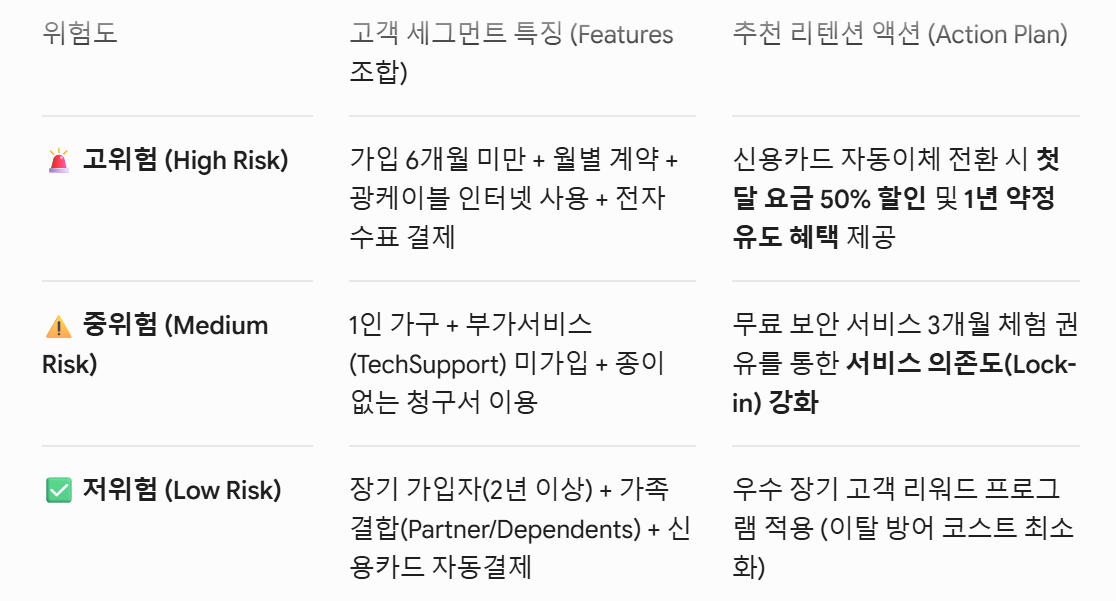

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 계약 형태(Contract)별 이탈(Churn) 비율 시각화
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn Label', palette='Set2')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count of Customers')
plt.show()


#1단계. EDA & 모델 탐지
1.통계적 데이터 분석 (EDA)

2.피처 엔지니어링 (Feature Engineering)

3.Baseline 모델 구축


In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df.info()

In [ ]:
import pandas as pd
import numpy as np
if 'real_filename' not in globals() or not os.path.exists(real_filename):
    real_filename = get_data_path()
df = pd.read_csv(real_filename)

# 데이터 초기화 (기본 csv에서 다시 깨끗하게 로드)

# 1. Total Charges 공백 제거 및 결측치 처리
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())

# 2. 이진 변수 매핑 (Yes/No -> 1/0)
yes_no_mapping = {'Yes': 1, 'No': 0, 'No internet service': 0}
cols_to_map = [
    'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 
    'Online Security', 'Online Backup', 'Device Protection', 
    'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing'
]
for col in cols_to_map:
    if col in df.columns:
        df[col] = df[col].map(yes_no_mapping)

# Gender: Female -> 0, Male -> 1
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

# Multiple Lines: No -> 0, No phone service -> 1, Yes -> 2
if 'Multiple Lines' in df.columns:
    df['Multiple Lines'] = df['Multiple Lines'].map({'No': 0, 'No phone service': 1, 'Yes': 2})

# Internet Service: DSL -> 0, Fiber optic -> 1, No -> 2
if 'Internet Service' in df.columns:
    df['Internet Service'] = df['Internet Service'].map({'DSL': 0, 'Fiber optic': 1, 'No': 2})

# Contract: Month-to-month -> 0, One year -> 1, Two year -> 2
if 'Contract' in df.columns:
    df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

# Payment Method 매핑
if 'Payment Method' in df.columns:
    payment_map = {
        'Electronic check': 0,
        'Mailed check': 1,
        'Bank transfer (automatic)': 2,
        'Credit card (automatic)': 3
    }
    df['Payment Method'] = df['Payment Method'].map(payment_map)

# 타겟 변수 Churn 생성 (이전 코드 호환용)
if 'Churn Value' in df.columns:
    df['Churn'] = df['Churn Value']
elif 'Churn Label' in df.columns:
    df['Churn'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

# 도시(City) 빈도수 인코딩
if 'City' in df.columns:
    city_freq = df['City'].value_counts()
    df['City_Encoded'] = df['City'].map(city_freq)


In [ ]:
df.info()

In [ ]:
df.head((100))

In [ ]:
# 다중 범주형 및 주요 매핑 정보 정의 (딕셔너리)
mapping_info = {
    "Gender": {'Female': 0, 'Male': 1},
    "Multiple Lines": {'No': 0, 'No phone service': 1, 'Yes': 2},
    "Internet Service": {'DSL': 0, 'Fiber optic': 1, 'No': 2},
    "Contract": {'Month-to-month': 0, 'One year': 1, 'Two year': 2},
    "Payment Method": {
        'Electronic check': 0,
        'Mailed check': 1,
        'Bank transfer (automatic)': 2,
        'Credit card (automatic)': 3
    },
    "Yes/No 공동 적용 열 (Partner, Dependents, Senior Citizen 등)": {'Yes': 1, 'No': 0, 'No internet service': 0}
}

print("=" * 60)
for column_name, mapping in mapping_info.items():
    print(f"\n▶ [열 이름: {column_name}]")
    print("-" * 40)
    for original_value, encoded_num in mapping.items():
        print(f"   • 기존 값: {original_value:<30} ➔  부여된 숫자: {encoded_num}")
    print("-" * 40)
print("=" * 60)


In [ ]:
# Train_test_split and logistic regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. 독립변수(X)와 종속변수(y, Churn) 분리
# ----------------------------------------------------
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Lat Long', 'Churn Label', 'Churn Value', 'Churn Reason', 'Churn Score', 'Churn']
feature_cols = [c for c in df.columns if c not in drop_cols and df[c].dtype in ['int64', 'float64']]
X = df[feature_cols]
y = df['Churn']

# ----------------------------------------------------
# 2. train_test_split으로 데이터 쪼개기 (8:2)
# ----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"학습용 데이터 크기: {X_train.shape}")
print(f"검증용 데이터 크기: {X_test.shape}\n")

# ----------------------------------------------------
# 3. Baseline 모델(Logistic Regression) 학습
# ----------------------------------------------------
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

# ----------------------------------------------------
# 4. 모델 예측 및 평가
# ----------------------------------------------------
y_pred = model_lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("📊 [Baseline: Logistic Regression 평가 결과]")
print("=" * 50)
print(f"• 정확도 (Accuracy)  : {accuracy:.4f}")
print(f"• 정밀도 (Precision) : {precision:.4f} -> 이탈이라고 예측한 사람 중 진짜 이탈한 비율")
print(f"• 재현율 (Recall)    : {recall:.4f} -> 진짜 이탈한 사람 중 모델이 맞춘 비율 (★핵심 지표★)")
print(f"• F1-Score          : {f1:.4f} -> 정밀도와 재현율의 조화 평균")
print("=" * 50)

# ----------------------------------------------------
# 5. 오차 행렬 (Confusion Matrix) 시각화
# ----------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stay (0)', 'Churn (1)'],
            yticklabels=['Stay (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


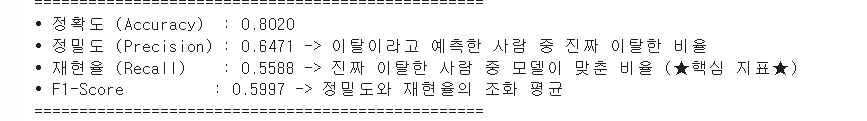

#Baseline : 재현율 , 정밀도 등 지표가 매우 낮게 나타남 -> random forest나 light bgm 으로 성능향상

# 데이터 추가 분석 ( appendix )
-Pearson Correlation ->  target: churn , -1~1 ( -1: 유지율이 높다  , +1 : 이탈율이 높다)

In [ ]:
# 각 지표가 이탈율에 미치는 영향 분석
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 수치형/인코딩 변수 간 상관계수 행렬 계산
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Zip Code', 'Latitude', 'Longitude', 'Churn Score'], errors='ignore')
corr_matrix = numeric_df.corr()

# 2. 타겟 변수(Churn)와 다른 변수들 간의 상관계수만 추출 후 내림차순 정렬
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(ascending=False)

print("=" * 50)
print("📊 [각 변수별 Churn(이탈률)과의 상관계수 순위]")
print("=" * 50)
for col, val in churn_corr.items():
    print(f"• {col:<30} : {val:+.4f}")
print("=" * 50)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 1: Churn 기준 상관계수 Barplot
plt.figure(figsize=(12, 8))
colors = ['#ff6b6b' if x > 0 else '#4dabf7' for x in churn_corr.values]
sns.barplot(x=churn_corr.values, y=churn_corr.index, palette=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Correlation with Churn (Target Variable)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 시각화 2: 전체 변수 간의 Correlation Heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            mask=mask, linewidths=0.5, cbar_kws={"shrink": .8}, annot_kws={"size": 8})
plt.title('Overall Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


#Question : 총요금이 높을수록 이탈율이 높아져야되는거아닌가?

Ans: Tontal charge = tenure * Monthly charge

장기 고객의 특성: 아무리 월별 요금이 저렴하더라도 5년 동안 서비스를 유지한 고객-> 총요금 증가

초기 고객의 특성 : 월 요금이 비싸더라도 가입한지 별로 안된 초기 고객의 경우 총요금 작다

# 가입 기간 및 인터넷 서비스 별 '이탈위험' 분석

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
if 'real_filename' not in globals() or not os.path.exists(real_filename):
    real_filename = get_data_path()
df_analysis = pd.read_csv(real_filename)

# 1. 데이터 로드 및 이탈 고객(Churn Label == Yes)만 필터링

df_churn_only = df_analysis[df_analysis['Churn Label'] == 'Yes'].copy()

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# [그래프 1] 이탈 고객의 가입 기간(Tenure Months) 분포
plt.figure(figsize=(10, 4.5))
sns.histplot(data=df_churn_only, x='Tenure Months', bins=36, color='#ff6b6b', kde=True, alpha=0.7)
plt.title('Distribution of Churn Customers by Tenure Months (When do they leave?)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tenure Months (at the time of churn)', fontsize=11)
plt.ylabel('Count of Churned Customers', fontsize=11)
plt.xlim(0, 72)
plt.tight_layout()
plt.show()

# [그래프 2] 이탈 고객의 인터넷 서비스 유형
plt.figure(figsize=(9, 4.5))
sns.countplot(data=df_churn_only, x='Internet Service', palette='Reds_r', order=df_churn_only['Internet Service'].value_counts().index)
plt.title('Internet Service Type among Churned Customers (Which service is high risk?)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Internet Service Type', fontsize=11)
plt.ylabel('Count of Churned Customers', fontsize=11)
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# [그래프 3] 이탈 고객의 부가서비스(Lock-in) 가입 개수
service_list = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']
df_churn_only['Total_Services'] = df_churn_only[service_list].apply(lambda x: x == 'Yes').sum(axis=1)

plt.figure(figsize=(10, 4.5))
sns.countplot(data=df_churn_only, x='Total_Services', palette='Purples_r')
plt.title('Subscribed Lock-in Services among Churned Customers', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Number of Subscribed Services (0 to 6)', fontsize=11)
plt.ylabel('Count of Churned Customers', fontsize=11)
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


#결합상품 개수에 따른 이탈률 분석

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
if 'real_filename' not in globals() or not os.path.exists(real_filename):
    real_filename = get_data_path()
df_lockin = pd.read_csv(real_filename)


df_lockin['Churn_num'] = df_lockin['Churn Label'].map({'Yes': 1, 'No': 0})
service_list = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']
df_lockin['Total_Services'] = df_lockin[service_list].apply(lambda x: x == 'Yes').sum(axis=1)

churn_rate_by_services = df_lockin.groupby('Total_Services')['Churn_num'].mean().reset_index()
churn_rate_by_services['Churn_Rate_%'] = churn_rate_by_services['Churn_num'] * 100

print("=" * 50)
print("📊 [결합 상품 가입 개수별 실제 이탈률 통계]")
print("=" * 50)
for idx, row in churn_rate_by_services.iterrows():
    print(f"• 부가서비스 {int(row['Total_Services'])}개 가입 고객의 이탈률 : {row['Churn_Rate_%']:.2f}%")
print("=" * 50)

plt.figure(figsize=(10, 5.5))
sns.barplot(data=churn_rate_by_services, x='Total_Services', y='Churn_Rate_%', palette='coolwarm_r', alpha=0.85)
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Actual Churn Rate by Number of Subscribed Services', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Subscribed Services (0 to 6)', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.ylim(0, 55)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


고객이 이용하는 결합 상품의 개수가 높아질수록 이탈률이 지속적으로 줄어둠 , 특히 3개 이상일 때 30% 이하로 3개 이상으로 패키징할 때 좋은 전략이 될 수 있을 것이라 생각함

#2단계. Segmentation & modeling
1. 고객 segmentation - k_means clustering or DBSCAN
2. Decision Tree , Random Forest (정보이득 , 지니 불순도)



#3단계. LightGBM 모델 튜빙 및 모델 평가

    1. Light GBM & Hyperparameter tuning  : Leaf wise 성장 방식 ,(max_depth, learning rate , num_leaves)
    
    2.불균형 데이터 처리 및 recall(최적화) : SMOTE같은 오버 샘플링 기법 ,False negative 줄이기

    3.SHAP 분석 및 리텐션 전략
    - Shapely additive exPlanations
    -리텐션 전략 (ex) 약정 기간이 끝난 고객에게 결합 할인 혜택 제안하는 자동화 스크립트 작성
    